In [1]:
import pandas as pd

In [2]:
#Series
#1 dimentional labelled array that represents a single column
#series are homogenous
#vectorized operations 
#handles missing values with Nan
#elements(values) are mutable but number of entries are immutable.
#if you try to change the number of entries and add or delete some entries then a new series will be created
#You cannot directly increase or decrease its size like you do with a list.

s=pd.Series([1,2,3,4,5])
print(s)
print(type(s))

#index based access
print(s[0])
print(s[1:4])

#elements(values) are mutable but number of entries(size) are immutable.
s[1]=100
print(s)
#if you try to change the number of entries and add or delete some entries then a new series will be created
changed_s=s1.drop(0)

print("changed s:\n",changed_s)
print("original s:\n",s)

#another series with labels
s=pd.Series([23,34,24,25,21],index=["ali","adam","bob","eve","sam"])
print(s)
#access with label
print(s["ali"]) #label=named index
print(s[0]) 
print(s.index)


#vectorized operations
s1=pd.Series([1,2,3,4,5])
s2=pd.Series([10,20,30,40,50])
print(s1+s2)




0    1
1    2
2    3
3    4
4    5
dtype: int64
<class 'pandas.core.series.Series'>
1
1    2
2    3
3    4
dtype: int64
0      1
1    100
2      3
3      4
4      5
dtype: int64


NameError: name 's1' is not defined

In [ ]:
#DataFrame
#2 dimentional labelled array 
#A Data Frame is fundamentally a collection of Series arranged side-by-side
#Because each column is its own Series, you can store completely different data types (e.g., text, numbers, dates) across the table while keeping the data type inside a single column uniform

#create datafram from dictionary
s={
    "name":["ali","ahmad","sam","arslan"],
    "age":[23,24,25,21],
    "cgpa":[3.1,3.5,3.4,3.6]
}
df=pd.DataFrame(s,index=[1,2,3,4])
print(df)
print()
print(df.index)
print(df.columns)


#create DF from lists in list
df=pd.DataFrame([["adam",23],["bob",24],["ahmad",34]],columns=["name","age"])
print(df)

#create DF from np arrays
import numpy as np
np_arr=np.array([[1,2,3],[4,5,6]])
df=pd.DataFrame(np_arr,columns=["a","b","c"])
print(df)

In [ ]:
#working with csv
df=pd.read_csv("employee_data.csv")
print(df,type(df))


In [ ]:
#json data
import json
df=pd.read_json("employee_data.json")
print(df,type(df))

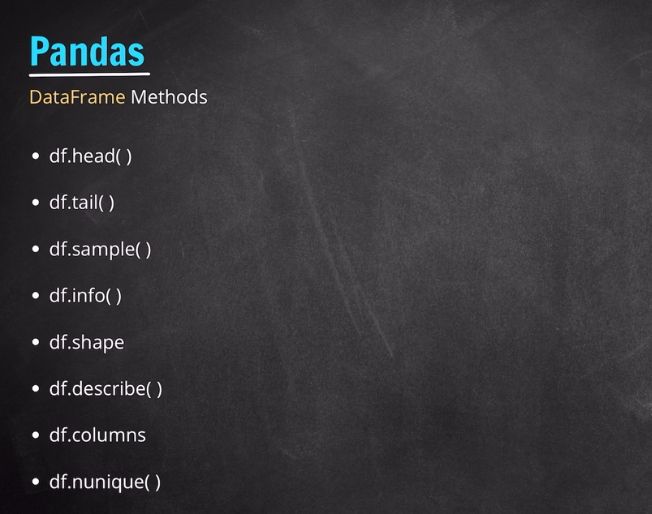


In [ ]:
#methods
df.head() #first 5 rows
df.head(3) #first 3 rows
df.tail() #last 5 rows
df.tail(2) #last two rows
df.sample() #random sample row
df.sample(3) # 3 random rows
df.info() #gives basic info
df.shape #returns tuple of (row , col)
df.describe() #describe the data--- basic information for numerical cols only - mean,count,std etc
df.nunique() #number of unique values

In [3]:
#working on global ari quality kaggle dataset
df=pd.read_csv("globalAirQuality.csv")
df.describe()
df.head()

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,2025-11-04 18:25:17.554219,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
1,2025-11-04 19:25:17.554219,US,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969
2,2025-11-04 20:25:17.554219,US,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650
3,2025-11-04 21:25:17.554219,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
4,2025-11-04 22:25:17.554219,US,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017


In [13]:
#selecting data --- INDEXING

#COLUMNS

df["country"]
df[["city","aqi"]]


#ROWS 

#label based #loc  --- takes label value
df.loc[0] #first row data
df.loc[0:3] #first 4 rows -- end index inclusive 

#index based #iloc --- requires numeric indexers -- no strings
df.iloc[0]
df.iloc[0:2] #first two rows -- end index exclusive

df.loc[0,"aqi"]             
df.loc[0,["city","aqi"]]
df.loc[0:2,["city","aqi"]]    #0,1,2 row

#iloc needs numerical index value
df.iloc[0:2,2] #print city values for first two rows

#loc and iloc (below two give same output)
df.loc[0:2, ["country","city","latitude","longitude"]] ##first 3 rows and the given columns
df.iloc[0:3, 1:5] #first 3 rows and 1-4 columns


#INDIVIDUAL CELL --- use at and iat
df.at[0,"city"]
#or
df.iat[0,2] #2 is the index of city


#PANDAS ALSO RETURNS VIEW OF THE ORIGINAL DATA (as does numpy). IT DOES NOT EXPLICITLY CREATE A COPY. I YOU MAKE CHANGES IN THE VIEW, ORIGINAL FILE DATA WILL GET CHANGED. TO AVOID THIS, USE .COPY() FUNCTION TO EXPLICITLY CREATE A COPY OF THE DATA IN A NEW VARIABLE
cities= df["city"].copy()
#making any change to the copy will not alter original file data





In [8]:
#FILTERING OF DATA
df[ df["aqi"] > 150] #print all values where aqi > 100
df[ (df["aqi"] > 150) & (df["temperature"]>35)]

aqi_data=df[ (df["aqi"] > 150) & (df["temperature"]>35) ] [["city","aqi"]]
aqi_data.iloc[0]

# aqi_data.loc[1] #error because this 1 does not exist in our data
aqi_data.loc[6] #correct


city    New York
aqi          155
Name: 6, dtype: object

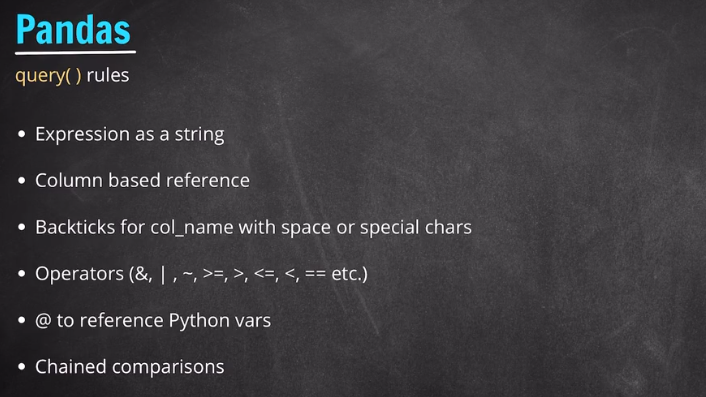

In [14]:
#Query method
df.query("aqi > 150") #case sensitive column values
#chained comparison
df.query("aqi > 150 & temperature>30")
df.query("aqi > 150 & temperature>30")[["city","aqi"]] # print city and aqi only

#using variable value in query
val=200
df.query("aqi > @val")

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
745,2025-11-05 19:25:17.554219,GB,London,51.507,-0.128,107.144,43.819,13.389,4.601,21.680,0.890,214,19.055,66.245,1.637
8941,2025-11-17 07:25:17.554219,JP,Osaka,34.694,135.502,102.142,95.204,41.688,7.806,28.951,0.753,204,15.277,76.131,4.586
12956,2025-11-19 14:25:17.554219,NZ,Auckland,-36.848,174.763,44.824,66.657,90.019,3.637,41.311,0.849,225,14.872,63.319,0.958
14555,2025-11-11 05:25:17.554219,PH,Manila,14.600,120.984,103.023,66.678,43.284,2.167,48.250,0.849,206,11.027,63.522,7.635
17458,2025-11-12 04:25:17.554219,FI,Helsinki,60.170,24.938,14.329,51.173,81.111,7.725,61.160,1.383,202,34.420,26.061,3.771
17529,2025-11-15 03:25:17.554219,FI,Helsinki,60.170,24.938,115.683,81.714,54.764,6.687,39.552,0.685,231,25.795,87.839,6.705
17815,2025-11-12 01:25:17.554219,CH,Zurich,47.377,8.542,54.805,39.178,81.406,10.241,46.579,0.498,203,20.883,70.201,3.500


### Data Transformation

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,2025-11-04 18:25:17.554219,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
1,2025-11-04 19:25:17.554219,US,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969
2,2025-11-04 20:25:17.554219,US,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650
3,2025-11-04 21:25:17.554219,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
4,2025-11-04 22:25:17.554219,US,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,2025-11-19 13:25:17.554219,CH,Zurich,47.377,8.542,27.899,74.179,41.474,6.677,50.869,1.028,103,7.079,52.443,7.452
17996,2025-11-19 14:25:17.554219,CH,Zurich,47.377,8.542,2.950,47.988,42.235,2.821,35.551,0.644,105,28.734,85.678,4.496
17997,2025-11-19 15:25:17.554219,CH,Zurich,47.377,8.542,61.347,72.908,46.976,5.763,66.492,0.947,122,21.951,72.311,9.660
17998,2025-11-19 16:25:17.554219,CH,Zurich,47.377,8.542,40.722,95.152,32.957,5.524,53.193,0.868,95,24.042,31.880,2.642
